## Data

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import arviz as az
import json

n_typs = ["a2a", "thin", "ltsi", "pv", "d1"]
neuron_type = n_typs[0]

with open(f"Neuronal_data/gpData_{neuron_type}_mdms_phase6_wholeTrial_40Hz.json", 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data['trials'])
print(data['codebook'])

sampling_frequency = data['samplingRateHz']
time_step_ms = data['dtMs']
n_animals = len(df['animalID'].unique())
group = data['cellType']

{'trialOutcome': '1=reward, 2=unreward', 'prevTrialOutcome': '1=previous reward, 2=previous unreward', 'pushPull': '1=push, 2=pull'}


In [18]:
CONFIG = {
    "grid_span": 120,              # How many points per HSGP
    "time_length_ms": 3000,        # How much time to infer for each predictor function
    "max_trial_len": 40000,        # Raw timepoints before binning
    "n_animals_to_load": n_animals,  # Limit for testing (set None for all)
    "predictors": "bin",           # None, "cont" or "bin"
    "group": group,
}
CONFIG["bin_size"] = int(CONFIG["time_length_ms"] / CONFIG["grid_span"])
CONFIG["time_length_ms"] = CONFIG["bin_size"] * CONFIG["grid_span"]
print(f"Time length per function: {CONFIG['time_length_ms']} ms")

#   Predictor definitions  
map_0 = 0
map_1 = map_0 + 1
filters = {
    "prevTrialOutcome": {"Predictor": 1, "Present": 1, "Binary": True, "Map": {1: map_1, 2: map_0}, "Value": 1},
    "trialOutcome": {"Predictor": 1, "Present": 1, "Binary": True, "Map": {1: map_1, 2: map_0}, "Value": 1},
    "pushPull": {"Predictor": 1, "Present": 1, "Binary": True, "Map": {1: map_1, 2: map_0}, "Value": 1},
}

filename = "trace_"
for i, v in enumerate(filters.items()):
    if v[1]["Predictor"]:
        filename += f"{i+1}"
filename += "_" + CONFIG["group"]
if map_0 == -0.5:
    filename += "_05"
print("filename is: ", filename)

#   Trial filtering  
for col, k in filters.items():
    if not k["Present"]:
        if "Logic" in k and k["Logic"] == "geq":
            df = df[df[col] >= k["Value"]]
        elif "Logic" in k and k["Logic"] == "leq":
            df = df[df[col] <= k["Value"]]
        else:
            df = df[df[col] == k["Value"]]

print(f"Data loaded. Total valid trials: {len(df)}")

Time length per function: 3000 ms
filename is:  trace_123_a2a
Data loaded. Total valid trials: 4483


## Processing and Standardization

In [19]:
processed_data = []  # Stores dicts of {y, predictors, delay, len} per subject

unique_animals = df["animalID"].unique()
if CONFIG["n_animals_to_load"]:
    unique_animals = unique_animals[:CONFIG["n_animals_to_load"]]

# Intercept + Binary flags + Continuous flags
binary_cols = ['intercept'] + [k for k, v in filters.items() if v["Present"] and v["Binary"]]
continuous_cols = [k for k, v in filters.items() if v["Present"] and not v["Binary"]]
all_pred_names = binary_cols + continuous_cols

print(f"Processing {len(unique_animals)} animals...")
print(f"Predictors: {all_pred_names}")

Processing 8 animals...
Predictors: ['intercept', 'prevTrialOutcome', 'trialOutcome', 'pushPull']


In [20]:

for animal_id in unique_animals:
    sub_df = df[df["animalID"] == animal_id]

    sub_y = []
    sub_delays = []
    sub_preds = []

    for _, trial in sub_df.iterrows():
        valid_len = len(trial["y"])
        if valid_len == 0 or valid_len > CONFIG["max_trial_len"]:
            continue

        photo_bin = np.array(trial["y"][:valid_len])
        ts_bin = np.array(trial["tRelGoMs"][:valid_len])
        sub_y.append(photo_bin)

        # Delay: relative time of event from Go cue, converted to bin index
        delay_time = trial["outcomeRelToGoMs"] + 1000  # 1s pre-GO offset in data
        delay_idx = np.argmin(np.abs(ts_bin - ts_bin[0] - delay_time))
        sub_delays.append([40, delay_idx])  # Func 0 = GoCue (fixed at 40), Func 1 = event

        # Predictors: intercept, binary (mapped), continuous (raw, standardized later)
        row_preds = [1.0]
        for col in binary_cols[1:]:
            val = trial[col]
            mapping = filters[col]["Map"]
            row_preds.append(mapping[val])
        for col in continuous_cols:
            row_preds.append(trial[col])
        sub_preds.append(row_preds)

    if len(sub_y) > 0:
        processed_data.append({
            "y": np.concatenate(sub_y),
            "trial_lens": [len(y) for y in sub_y],
            "delays": np.array(sub_delays),
            "preds": np.array(sub_preds),
        })

# Global dimensions
n_subs = len(processed_data)
n_trials = max(len(d["trial_lens"]) for d in processed_data)
n_time_max = max(max(d["trial_lens"]) for d in processed_data)
n_pred_funcs = 2
n_trials_total = sum(len(d["trial_lens"]) for d in processed_data)

print(f"Number of trials: {n_trials_total}")

Number of trials: 4483


In [21]:
max_total_len = max(len(d["y"]) for d in processed_data)

y_noisy_stacked = xr.DataArray(
    np.full((n_subs, max_total_len), np.nan, dtype='float32'),
    coords={'subject': range(n_subs), 'trialXtime': range(max_total_len)},
)

delays = xr.DataArray(
    np.full((n_subs, n_trials, n_pred_funcs), 0, dtype='int32'),
    coords={'subject': range(n_subs), 'trial': range(n_trials), 'func': range(n_pred_funcs)},
)

trial_lens_xr = xr.DataArray(
    np.full((n_subs, n_trials), 0, dtype='int32'),
    coords={'subject': range(n_subs), 'trial': range(n_trials)},
)

# Predictor standardization stats (NaN-robust)
all_cont_preds = [processed_data[s]["preds"][:, len(binary_cols):] for s in range(n_subs)]
flat_cont = np.concatenate(all_cont_preds, axis=0)

mean_preds = np.nanmean(flat_cont, axis=0)
std_preds = np.nanstd(flat_cont, axis=0)
std_preds[std_preds == 0] = 1.0

# Populate arrays & standardize continuous predictors
unified_pred_list = []

for s in range(n_subs):
    d = processed_data[s]

    y_noisy_stacked.values[s, :len(d["y"])] = d["y"]
    n_tr = len(d["trial_lens"])
    trial_lens_xr.values[s, :n_tr] = d["trial_lens"]
    delays.values[s, :n_tr, :] = d["delays"]

    p_data = d["preds"].copy()
    cont_data = p_data[:, len(binary_cols):]

    # Temporarily fill NaNs with the global mean (equals 0 after standardization)
    nan_mask = np.isnan(cont_data)
    for i in range(cont_data.shape[1]):
        col_mask = nan_mask[:, i]
        if np.any(col_mask):
            cont_data[col_mask, i] = mean_preds[i]

    p_data[:, len(binary_cols):] = (cont_data - mean_preds) / std_preds

    pad_width = n_trials - n_tr
    if pad_width > 0:
        p_padded = np.pad(p_data, ((0, pad_width), (0, 0)), constant_values=0)
        unified_pred_list.append(p_padded)
    else:
        unified_pred_list.append(p_data)

unified_pred_tensor = np.stack(unified_pred_list)

print(f"Predictor Tensor Shape: {unified_pred_tensor.shape}")
print(f"Any NaNs remaining? {np.isnan(unified_pred_tensor).any()}")
print(f"Y Shape: {y_noisy_stacked.shape}")

Predictor Tensor Shape: (8, 923, 4)
Any NaNs remaining? False
Y Shape: (8, 204242)


In [22]:
# PREDICTOR SELECTION LAYER

SELECTED_PREDICTORS = [p for p in all_pred_names if p == "intercept" or filters[p]["Predictor"]]

print(f"\n  Sub-selecting Predictors  ")
print(f"Original available: {all_pred_names}")

try:
    keep_indices = [all_pred_names.index(p) for p in SELECTED_PREDICTORS]
    unified_pred_tensor = unified_pred_tensor[:, :, keep_indices]

    all_pred_names = SELECTED_PREDICTORS
    n_unified_preds = len(all_pred_names)

    print(f"Final predictors for model: {all_pred_names}")
    print(f"New Tensor Shape: {unified_pred_tensor.shape}")
except ValueError as e:
    print(f"Error: A selected predictor was not found in the loaded data.\n{e}")
    raise


  Sub-selecting Predictors  
Original available: ['intercept', 'prevTrialOutcome', 'trialOutcome', 'pushPull']
Final predictors for model: ['intercept', 'prevTrialOutcome', 'trialOutcome', 'pushPull']
New Tensor Shape: (8, 923, 4)


In [23]:

# FUNCTION SELECTION LAYER

AVAILABLE_FUNC_MAP = {
    "GoCue": 0,
    "ChoiceOutcome": 1,
    # "NewEvent": 2,
}

SELECTED_FUNCS = [
    "GoCue",
    "ChoiceOutcome",
]

print(f"\n  Sub-selecting Functions  ")
print(f"Available: {list(AVAILABLE_FUNC_MAP.keys())}")

try:
    func_indices = [AVAILABLE_FUNC_MAP[name] for name in SELECTED_FUNCS]

    delays = delays.isel(func=func_indices)

    # processed_data must also be updated: the grid calculation below iterates over it
    for s in range(n_subs):
        original_delays = processed_data[s]["delays"]
        processed_data[s]["delays"] = original_delays[:, func_indices]

    n_pred_funcs = len(SELECTED_FUNCS)
    func_names_for_plots = SELECTED_FUNCS

    print(f"Final Functions for model: {func_names_for_plots}")
    print(f"New Delay Shape: {delays.shape}")
except KeyError as e:
    print(f"Error: A selected function is not defined in AVAILABLE_FUNC_MAP.\n{e}")
    raise



  Sub-selecting Functions  
Available: ['GoCue', 'ChoiceOutcome']
Final Functions for model: ['GoCue', 'ChoiceOutcome']
New Delay Shape: (8, 923, 2)


## Model Preparation

In [24]:

#   1. Grid configuration  
grid_span = CONFIG["grid_span"]

# Start of the grid relative to each function's event (index-aligned with func_indices)
func_offsets_ms = np.array([-1000, -1000])
func_offsets = [np.round(func_offsets_ms[i] / CONFIG["bin_size"]).astype(int) for i in func_indices]
print(f"Function Offsets: {func_offsets}")

# Canonical grid the model sees (0..grid_span); plotting maps it back to real time
X_grid = np.arange(grid_span + 1)
n_grid = len(X_grid)

#   2. Time index matrix (T_idx), with per-function shifts  
time_indices = np.full((n_subs, max_total_len, n_pred_funcs), -1, dtype='int32')

for s in range(n_subs):
    d_list = processed_data[s]["delays"]
    len_list = processed_data[s]["trial_lens"]

    current_t = 0
    for tr, t_len in enumerate(len_list):
        t_trial = np.arange(t_len)

        for pf in range(n_pred_funcs):
            delay = d_list[tr, pf]
            t_rel = t_trial - delay
            func_start = func_offsets[pf]
            idx = (t_rel - func_start).astype(int)
            valid_idx_mask = (idx >= 0) & (idx < n_grid)

            global_slice = slice(current_t, current_t + t_len)
            temp_idx = np.full(t_len, -1, dtype='int32')
            temp_idx[valid_idx_mask] = idx[valid_idx_mask]
            time_indices[s, global_slice, pf] = temp_idx

        current_t += t_len

#   3. Unified predictor matrix, expanded to (Subject, Time, Predictor)  
n_unified_preds = unified_pred_tensor.shape[2]
unified_pred_matrix = np.zeros((n_subs, max_total_len, n_unified_preds), dtype='float32')

for s in range(n_subs):
    len_list = processed_data[s]["trial_lens"]
    current_t = 0
    for tr, t_len in enumerate(len_list):
        val = unified_pred_tensor[s, tr, :]
        unified_pred_matrix[s, current_t:current_t + t_len, :] = val
        current_t += t_len

#   4. Normalize Y (per-subject, NaN-robust) and build masks  
y_norm_values = np.zeros_like(y_noisy_stacked.values)

for s in range(n_subs):
    raw_s = y_noisy_stacked.values[s, :]
    mu_s = np.nanmean(raw_s)
    std_s = np.nanstd(raw_s)
    if std_s == 0:
        std_s = 1.0
    y_norm_values[s, :] = (raw_s - mu_s) / std_s

y_norm = xr.DataArray(y_norm_values, coords=y_noisy_stacked.coords)

has_valid_gp_support = (time_indices != -1).any(axis=2)
has_valid_data = ~np.isnan(y_noisy_stacked.values)
valid_mask = has_valid_gp_support & has_valid_data

function_active_mask = (time_indices != -1).astype('float32')
time_indices_clipped = np.clip(time_indices, 0, n_grid - 1)

print("Pre-Model Structures Ready:")
print(f"X_grid shape: {X_grid.shape} (Time basis)")
print(f"time_indices shape: {time_indices.shape} (Mapping)")
print(f"unified_pred_matrix shape: {unified_pred_matrix.shape} (Predictors)")
print(f"valid_mask sum: {valid_mask.sum()} (Valid data points)")

Function Offsets: [-40, -40]
Pre-Model Structures Ready:
X_grid shape: (121,) (Time basis)
time_indices shape: (8, 204242, 2) (Mapping)
unified_pred_matrix shape: (8, 204242, 4) (Predictors)
valid_mask sum: 848321 (Valid data points)


## Model

In [25]:
import pymc as pm
import pytensor.tensor as pt

n_basis = 40   # number of HSGP basis functions
c_factor = 1.5 # boundary extension factor, prevents edge effects

coords = {
    "subject": range(n_subs),
    "predictor": all_pred_names,
    "func": range(n_pred_funcs),
    "basis": range(n_basis),
    "grid_time": X_grid,
    "obs_dim_flat": np.arange(n_subs * max_total_len),
}

with pm.Model(coords=coords) as model:

    # Data containers. NaNs in Y are filled with 0 and excluded later via valid_mask.
    Y_data = pm.Data("Y_data", y_norm.fillna(0.0).values)
    P_mat = pm.Data("P_mat", unified_pred_matrix)
    T_idx = pm.Data("time_indices", time_indices_clipped)
    F_mask = pm.Data("func_mask", function_active_mask)
    Mask = pm.Data("valid_mask", valid_mask)

    # Lengthscales and amplitudes, shared population level and subject-level deviation.
    ls = pm.Gamma("ls", alpha=4, beta=3, dims="predictor")
    l_subj = pm.Gamma("l_subj", alpha=4, beta=3, dims="predictor")
    eta_pop = pm.Exponential("eta_pop", lam=0.5, dims="predictor")
    eta_subj = pm.Exponential("eta_subj", lam=3.0, dims="predictor")

    # HSGP basis: spectral densities and eigenfunctions computed once on the global grid.
    L = (X_grid.max() - X_grid.min()) * c_factor / 2.0
    j = np.arange(1, n_basis + 1)
    omega = (j * np.pi) / (2 * L)
    omega_sq = omega ** 2

    ls_exp = ls[:, None]
    ls_subj_exp = l_subj[:, None]

    def get_sqrt_psd(eta, l_scale):
        # ExpQuad kernel spectral density
        psd = (eta[:, None] ** 2) * pt.sqrt(2 * np.pi * l_scale ** 2) * pt.exp(-0.5 * l_scale ** 2 * omega_sq)
        return pt.sqrt(psd)

    def get_sqrt_psd_matern52(eta, l_scale):
        # Matern52 kernel spectral density
        lam = pt.sqrt(5.0) / l_scale
        psd = (eta[:, None] ** 2) * (16.0 * lam ** 5) / (3.0 * (lam ** 2 + omega_sq) ** 3)
        return pt.sqrt(psd)

    sqrt_psd_pop = get_sqrt_psd_matern52(eta_pop, ls_exp)
    sqrt_psd_subj = get_sqrt_psd_matern52(eta_subj, ls_subj_exp)

    x_centered = X_grid - (X_grid.max() + X_grid.min()) / 2.0
    Phi = 1.0 / pt.sqrt(L) * pt.sin(omega * (x_centered[:, None] + L))

    # Population coefficients, non-centered parametrization.
    z_pop = pm.Normal("z_pop", 0, 1, dims=("predictor", "func", "basis"))
    beta_pop = z_pop * sqrt_psd_pop[:, None, :]

    # Subject coefficients. ZeroSumNormal enforces that deviations average to zero across subjects,
    # so beta_pop remains the population mean. Transposed because it normalizes on the last dimension.
    z_subj_transposed = pm.ZeroSumNormal(
        "z_subj_transposed",
        sigma=1,
        dims=("predictor", "func", "basis", "subject"),
    )
    z_subj = pm.Deterministic(
        "z_subj",
        z_subj_transposed.transpose((3, 0, 1, 2)),
        dims=("subject", "predictor", "func", "basis"),
    )
    beta_subj = z_subj * sqrt_psd_subj[None, :, None, :]
    beta_total = beta_pop[None, ...] + beta_subj

    # Reconstruct the GP curve for every subject, predictor and function on the global grid.
    GP_global = pt.einsum('spfb,tb->spft', beta_total, Phi)

    # Align each subject's timeline to the right point of each function's curve using T_idx.
    subj_batch_idx = pt.repeat(pt.arange(n_subs), max_total_len)
    components_list = []

    for f in range(n_pred_funcs):
        gp_f = GP_global[:, :, f, :]
        idx_f = T_idx[:, :, f]

        gp_f_flat = gp_f.reshape((n_subs * n_unified_preds, n_grid))
        idx_f_repeated = pt.repeat(idx_f, n_unified_preds, axis=0)

        batch_idx = pt.arange(n_subs * n_unified_preds).dimshuffle(0, 'x')
        batch_idx = pt.repeat(batch_idx, max_total_len, axis=1)

        gp_gathered = gp_f_flat[batch_idx.flatten(), idx_f_repeated.flatten()]
        gp_gathered = gp_gathered.reshape((n_subs, n_unified_preds, max_total_len))

        P_mat_T = P_mat.transpose(0, 2, 1)
        mask_f = F_mask[:, :, f].dimshuffle(0, 'x', 1)

        contrib_f = gp_gathered * P_mat_T * mask_f
        components_list.append(contrib_f)

    # Sum contributions across functions and predictors to get the total mean per subject/time.
    total_tensor = pt.stack(components_list, axis=0).sum(axis=0)
    mu_total = total_tensor.sum(axis=1)

    # Hierarchical noise: subject-level sigma centered around a population-level sigma.
    sigma_pop = pm.HalfNormal("sigma_pop", sigma=0.2)
    sigma_subj = pm.HalfNormal("sigma_subj", sigma=sigma_pop * np.sqrt(2 / np.pi), dims="subject")
    sigma_total = sigma_subj[subj_batch_idx]

    # Keep only valid (non-padded, non-NaN) observations for the likelihood.
    flat_mask = valid_mask.flatten()
    mu_valid = pm.Deterministic("mu_valid", mu_total.flatten()[flat_mask])
    y_valid = Y_data.flatten()[flat_mask]
    sigma_valid = sigma_total.flatten()[flat_mask]

    nu = pm.Gamma("nu", 10, 0.5)
    pm.StudentT("y", mu=mu_valid, sigma=sigma_valid, nu=nu, observed=y_valid)

print("Model Built Successfully.")

Model Built Successfully.


## Inference

### Supporting Functions

In [26]:
def deterministic_vars_idata(model, idata, expand=False):
    """Compute all deterministic (non-observed, non-basic) variables for a trace's posterior."""
    determ_vars = [
        var.name for var in model.unobserved_RVs
        if var.name not in [v.name for v in model.basic_RVs] and var.name != 'y'
    ]

    posterior_data = xr.Dataset()

    print("Beginning computation of deterministic variables...")
    for dv in determ_vars:
        temp_posterior = pm.compute_deterministics(
            idata.posterior,
            model=model,
            var_names=[dv],
            progressbar=False,
            merge_dataset=False,  # returns a new dataset instead of merging in place
        )
        posterior_data = xr.merge([posterior_data, temp_posterior])
    print("Done.")

    if expand:
        idata.posterior = xr.merge([idata.posterior, posterior_data])
    else:
        return posterior_data


def inference_gpu(n_chains, model, draws=2000, tune=1000, chains=1,
                   logl=True, deterministic=True, thinning=1, verbose=False):
    """Run NUTS sampling on GPU via blackjax, one batch of chains at a time, then concatenate results."""
    n_loops = int(np.ceil(n_chains / chains))

    for i in range(n_loops):
        print(f"Starting chain {(i + 1) * chains}/{n_chains}")
        vars_to_sample = [var.name for var in model.basic_RVs]

        with model:
            idata_single_chain = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                cores=chains,
                target_accept=0.9,
                nuts={'max_treedepth': 12},
                var_names=vars_to_sample,
                idata_kwargs=dict(log_likelihood=False),
                nuts_sampler="blackjax",
                init="jitter+adapt_diag",
            )

        print(
            "Divergences: ", idata_single_chain.sample_stats.diverging.sum().values,
            "\t| min r_hat: ", az.rhat(idata_single_chain).max().to_array().values.max().round(4),
            "\t| min ess: ", az.ess(idata_single_chain).min().to_array().values.min().round(0),
            "\t| min ess tail: ", az.ess(idata_single_chain, method="tail").min().to_array().values.min().round(0),
        )

        if thinning > 1:
            print("Thinning")
            idata_single_chain = idata_single_chain.isel(draw=slice(None, None, thinning))
        else:
            print("NOT thinning")

        if deterministic:
            print("Computing deterministic variables")
            idata_single_chain.posterior = deterministic_vars_idata(model, idata_single_chain, expand=True)
        else:
            print("NOT computing deterministic variables")

        if logl:
            print("Computing log likelihood")
            pm.compute_log_likelihood(idata_single_chain, model=model, extend_inferencedata=True)
        else:
            print("NOT computing log likelihood")

        idata_list.append(idata_single_chain)
        print(f"Finished chain {(i + 1) * chains}/{n_chains}")

    if idata_list:
        idata = az.concat(idata_list, dim="chain")
    else:
        if verbose:
            print("No chains were sampled.")
    return idata

### Load

In [27]:
import os

In [28]:
# Single trace
print("Attempting loading " + filename)
file_name = "Neuronal_data/Idata_saved_multi/" + filename + ".nc"

if os.path.exists(file_name):
    if "trace" in locals():
        print("a trace variable already exists")
        if input("Overwrite? (y/n): ").lower() == "y":
            trace = az.from_netcdf(file_name)
            print("trace overwritten")
    else:
        print("trace file exists: loading")
        trace = az.from_netcdf(file_name)
        print("trace loaded")
else:
    print("WARNING: trace not yet saved.")

Attempting loading trace_123_a2a
a trace variable already exists


Overwrite? (y/n):  y


trace overwritten


In [29]:
# Multiple traces, one per neuron type
if "traces" not in locals():
    traces = {}

for neur in n_typs:
    filename_n = "Neuronal_data/Idata_saved_multi/trace_"
    for i, v in enumerate(filters.items()):
        if v[1]["Predictor"]:
            filename_n += f"{i+1}"
    filename_n += "_" + neur
    if map_0 == -0.5:
        filename_n += "_05"
    traces[neur] = az.from_netcdf(filename_n + ".nc")

### Run inference (GPU)

In [ ]:
n_chains = 4
idata_list = []
n_GPUs = 2
trace = inference_gpu(n_chains, model, draws=2000, tune=1000, chains=n_GPUs, thinning=1, logl=False, deterministic=False)

In [ ]:
deterministic_vars_idata(model, trace, expand = True)

In [30]:
print(
    "STAT FINAL:\n",
    "Divergences: ", trace.sample_stats.diverging.sum().values,
    "\t| min r_hat: ", az.rhat(trace).to_array().values.max().round(4),
    "\t| min ess: ", az.ess(trace).to_array().values.min().round(0),
    "\t| min ess tail: ", az.ess(trace, method="tail").to_array().values.min().round(0),
)

STAT FINAL:
 Divergences:  0 	| min r_hat:  1.0043 	| min ess:  2672.0 	| min ess tail:  3924.0


### Save

In [ ]:
file_name = "Neuronal_data/Idata_saved_multi/" + filename + ".nc"
print("Saving " + filename)

if os.path.exists(file_name):
    print("trace file exists")
    overwrite = input("Do you want to overwrite the file? (y/n) ")
    if overwrite.lower() == "y":
        os.remove(file_name)
        print("old file deleted")
        trace.to_netcdf(file_name)
        print("trace file saved")
    else:
        print("trace file not overwritten")
else:
    print("trace file does not exist")
    trace.to_netcdf(file_name)
    print("trace file saved")

## R^2

In [32]:
import json
import os

# Fixed quantities, recomputed in plain NumPy to mirror the model definitions exactly.
# NOTE: this duplicates the HSGP math from the model definition on purpose, so that R2
# can be computed from a saved trace (e.g. reloaded from disk) without needing a live
# PyMC model in memory. Keep this in sync if the model changes.

L = (X_grid.max() - X_grid.min()) * c_factor / 2.0
x_centered = X_grid - (X_grid.max() + X_grid.min()) / 2.0
j = np.arange(1, n_basis + 1)
omega = (j * np.pi) / (2 * L)
omega_sq = omega ** 2
Phi = (1.0 / np.sqrt(L) * np.sin(omega * (x_centered[:, None] + L))).astype("float64")

P_mat_T = unified_pred_matrix.transpose(0, 2, 1)

# Real observed data as plain NumPy, not the symbolic model tensor
y_flat = y_norm.fillna(0.0).values.flatten()
flat_mask = valid_mask.flatten()
y_valid_np = y_flat[flat_mask]

# Map every valid observation to its position in the likelihood vector
flat_index_map = np.full(valid_mask.shape, -1, dtype=np.int64)
flat_index_map[valid_mask] = np.arange(valid_mask.sum())

# Group valid observations by aligned grid bin, per function
obs_by_function_grid = {}
for f_idx, func_name in enumerate(func_names_for_plots):
    grid_idx = time_indices[:, :, f_idx]
    usable = valid_mask & (grid_idx >= 0)

    s_idx, t_idx = np.where(usable)
    aligned_bin = grid_idx[s_idx, t_idx]
    likelihood_idx = flat_index_map[s_idx, t_idx]

    obs_by_function_grid[func_name] = [
        likelihood_idx[aligned_bin == g] for g in range(n_grid)
    ]


def conditional_r2_by_bin(mu_draw, y_valid, obs_by_bin, min_n=20):
    """Conditional R2 per grid bin, using empirical residuals (Gelman et al. definition)."""
    r2 = np.full(len(obs_by_bin), np.nan)
    for g, idx in enumerate(obs_by_bin):
        if idx.size < min_n:
            continue
        resid = y_valid[idx] - mu_draw[idx]
        explained = np.var(mu_draw[idx], ddof=1)
        residual_var = np.var(resid, ddof=1)
        denom = explained + residual_var
        r2[g] = explained / denom if denom > 0 else np.nan
    return r2


def get_sqrt_psd_matern52_np(eta, l_scale, omega_sq):
    """Matern52 spectral density, batched over posterior draws and predictors."""
    lam = (np.sqrt(5.0) / l_scale)[..., None]
    eta_ = eta[..., None]
    psd = (eta_ ** 2) * (16.0 * lam ** 5) / (3.0 * (lam ** 2 + omega_sq[None, None, :]) ** 3)
    return np.sqrt(psd)


def reconstruct_mu_valid_batch(ls_b, l_subj_b, eta_pop_b, eta_subj_b, z_pop_b, z_subj_b):
    """
    Reconstruct mu_valid for a batch of posterior draws, mirroring the model's PyTensor math in NumPy.

    All *_b arrays carry a leading draw dimension D:
    ls_b, eta_pop_b, eta_subj_b, l_subj_b: (D, n_preds)
    z_pop_b: (D, n_preds, n_funcs, n_basis)
    z_subj_b: (D, n_subs, n_preds, n_funcs, n_basis)

    Returns mu_valid_batch: (D, n_valid_obs)
    """
    D = ls_b.shape[0]

    sqrt_psd_pop = get_sqrt_psd_matern52_np(eta_pop_b, ls_b, omega_sq)
    sqrt_psd_subj = get_sqrt_psd_matern52_np(eta_subj_b, l_subj_b, omega_sq)

    beta_pop = z_pop_b * sqrt_psd_pop[:, :, None, :]
    beta_subj = z_subj_b * sqrt_psd_subj[:, None, :, None, :]
    beta_total = beta_pop[:, None, :, :, :] + beta_subj

    GP_global = np.einsum('dspfb,tb->dspft', beta_total, Phi)

    mu_total_batch = np.zeros((D, n_subs, max_total_len), dtype="float64")

    for f in range(n_pred_funcs):
        gp_f = GP_global[:, :, :, f, :]
        idx_f = time_indices_clipped[:, :, f]
        idx_expand = np.broadcast_to(idx_f[None, :, None, :], (D, n_subs, n_unified_preds, max_total_len))
        gp_gathered = np.take_along_axis(gp_f, idx_expand, axis=-1)

        mask_f = function_active_mask[:, :, f][None, :, None, :]
        contrib_f = gp_gathered * P_mat_T[None, ...] * mask_f
        mu_total_batch += contrib_f.sum(axis=2)

    mu_valid_batch = mu_total_batch.reshape(D, -1)[:, flat_mask]
    return mu_valid_batch


def compute_r2_draws(trace, obs_by_function_grid, y_valid_np, n_grid, batch_size=250, min_n=20):
    """
    Compute conditional R2 per grid bin for every posterior draw, processed in batches to limit
    memory use. Works directly from a saved/reloaded trace, without requiring a live PyMC model.
    """
    post = trace.posterior.stack(sample=("chain", "draw"))
    n_total = post.sample.size

    r2_results = {
        func_name: np.full((n_total, n_grid), np.nan)
        for func_name in obs_by_function_grid.keys()
    }

    for start in range(0, n_total, batch_size):
        end = min(start + batch_size, n_total)
        batch = post.isel(sample=slice(start, end))

        ls_b = batch["ls"].values.T
        l_subj_b = batch["l_subj"].values.T
        eta_pop_b = batch["eta_pop"].values.T
        eta_subj_b = batch["eta_subj"].values.T
        z_pop_b = np.moveaxis(batch["z_pop"].values, -1, 0)
        z_subj_b = np.moveaxis(batch["z_subj"].values, -1, 0)

        mu_valid_batch = reconstruct_mu_valid_batch(ls_b, l_subj_b, eta_pop_b, eta_subj_b, z_pop_b, z_subj_b)

        for i in range(mu_valid_batch.shape[0]):
            mu_draw = mu_valid_batch[i]
            for func_name, obs_by_bin in obs_by_function_grid.items():
                r2_results[func_name][start + i, :] = conditional_r2_by_bin(mu_draw, y_valid_np, obs_by_bin, min_n=min_n)

        print(f"Processed draws {start}-{end} / {n_total}")

    return r2_results

def save_r2_results(r2_draws, obs_by_function_grid, filename_base, min_n=20, extra_metadata=None):
    """Save R2 draws (npz) and their metadata (json) under Neuronal_data/R2_saved."""
    save_dir = "Neuronal_data/R2_saved"
    os.makedirs(save_dir, exist_ok=True)

    npz_path = os.path.join(save_dir, f"{filename_base}_r2draws.npz")
    np.savez_compressed(npz_path, **r2_draws)

    n_obs_by_func = {
        func_name: [len(idx) for idx in obs_list]
        for func_name, obs_list in obs_by_function_grid.items()
    }

    metadata = {
        "func_names": list(r2_draws.keys()),
        "n_grid": int(next(iter(r2_draws.values())).shape[1]),
        "n_draws_total": int(next(iter(r2_draws.values())).shape[0]),
        "min_n": min_n,
        "n_obs_by_func": n_obs_by_func,
    }
    if extra_metadata:
        metadata.update(extra_metadata)

    meta_path = os.path.join(save_dir, f"{filename_base}_r2meta.json")
    with open(meta_path, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved R2 draws to: {npz_path}")
    print(f"Saved metadata to: {meta_path}")


def load_r2_results(filename_base):
    """Load R2 draws and metadata previously saved by save_r2_results."""
    save_dir = "Neuronal_data/R2_saved"
    npz_path = os.path.join(save_dir, f"{filename_base}_r2draws.npz")
    meta_path = os.path.join(save_dir, f"{filename_base}_r2meta.json")

    if not os.path.exists(npz_path) or not os.path.exists(meta_path):
        raise FileNotFoundError(f"Could not find saved R2 results for '{filename_base}'")

    loaded = np.load(npz_path)
    r2_draws_loaded = {key: loaded[key] for key in loaded.files}

    with open(meta_path, "r") as f:
        metadata = json.load(f)

    print(f"Loaded R2 draws for functions: {list(r2_draws_loaded.keys())}")
    print(f"Metadata: {metadata}")

    return r2_draws_loaded, metadata


# Compute (or load) R2 for the current population's trace.
# If a saved result already exists and recompute=False, it is loaded instead of recomputed.
recompute = False

save_dir = "Neuronal_data/R2_saved"
npz_path = os.path.join(save_dir, f"{filename}_r2draws.npz")
meta_path = os.path.join(save_dir, f"{filename}_r2meta.json")
already_saved = os.path.exists(npz_path) and os.path.exists(meta_path)

if already_saved and not recompute:
    print("Found saved R2, loading from disk")
    r2_draws, _ = load_r2_results(filename_base=filename)
else:
    print("Computing R2 from scratch")
    r2_draws = compute_r2_draws(
        trace=trace,
        obs_by_function_grid=obs_by_function_grid,
        y_valid_np=y_valid_np,
        n_grid=n_grid,
        batch_size=250,
        min_n=20,
    )
    save_r2_results(
        r2_draws,
        obs_by_function_grid,
        filename_base=filename,
        min_n=20,
        extra_metadata={"n_basis": n_basis, "n_subs": n_subs, "source_trace": filename},
    )

Found saved R2, loading from disk
Loaded R2 draws for functions: ['GoCue', 'ChoiceOutcome']
Metadata: {'func_names': ['GoCue', 'ChoiceOutcome'], 'n_grid': 121, 'n_draws_total': 8000, 'min_n': 20, 'n_obs_by_func': {'GoCue': [4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483], 'ChoiceOutcome': [4483, 4483, 4483, 4483, 4483, 4

## Corrected Population Effect

From this point onward, `traces` must already contain one saved/reloaded 
trace for every neuronal population you want to include in the study.
The corrected population curves and the final JSON export both iterate over traces.keys(),
so make sure inference has been run (or previous results reloaded) for all of them first.

In [42]:
# Settings
ALIGNMENT = "ChoiceOutcome"  # "GoCue" or "ChoiceOutcome"
N_POSTERIOR_SAMPLES = 2000   # None to use every stored draw
RANDOM_SEED = 20260902
CI_LEVEL = 0.95

f_idx_align = func_names_for_plots.index(ALIGNMENT)
lower_q = (1.0 - CI_LEVEL) / 2.0
upper_q = 1.0 - lower_q


def compute_corrected_beta_pop(trace, pred_name, func_idx, sample_indices,
                               X_grid, n_basis, c_factor, rng):
    """Reconstruct beta_pop and add the 1/sqrt(G) between-subject uncertainty correction."""
    n_subj_this_group = trace.posterior["z_subj"].sizes["subject"]
    post = trace.posterior.stack(sample=("chain", "draw")).isel(sample=sample_indices)
    n_draws = post.sizes["sample"]

    L_local = (X_grid.max() - X_grid.min()) * c_factor / 2.0
    x_centered_local = X_grid - (X_grid.max() + X_grid.min()) / 2.0
    j_local = np.arange(1, n_basis + 1)
    omega_local = (j_local * np.pi) / (2 * L_local)
    omega_sq_local = omega_local ** 2
    Phi_local = (
        1.0 / np.sqrt(L_local)
        * np.sin(omega_local * (x_centered_local[:, None] + L_local))
    )

    ls_pop_val = post["ls"].sel(predictor=pred_name).values
    eta_pop_val = post["eta_pop"].sel(predictor=pred_name).values
    z_pop_val = (
        post["z_pop"]
        .sel(predictor=pred_name, func=func_idx)
        .transpose("sample", "basis")
        .values
    )

    lam_pop = np.sqrt(5.0) / ls_pop_val[:, None]
    psd_pop = (
        eta_pop_val[:, None] ** 2
        * (16.0 * lam_pop ** 5)
        / (3.0 * (lam_pop ** 2 + omega_sq_local[None, :]) ** 3)
    )
    sqrt_psd_pop = np.sqrt(psd_pop)
    beta_pop = z_pop_val * sqrt_psd_pop
    pop_curves = (Phi_local @ beta_pop.T).T

    l_subj_val = post["l_subj"].sel(predictor=pred_name).values
    eta_subj_val = post["eta_subj"].sel(predictor=pred_name).values

    lam_subj = np.sqrt(5.0) / l_subj_val[:, None]
    psd_subj = (
        eta_subj_val[:, None] ** 2
        * (16.0 * lam_subj ** 5)
        / (3.0 * (lam_subj ** 2 + omega_sq_local[None, :]) ** 3)
    )
    sqrt_psd_subj = np.sqrt(psd_subj)
    sqrt_psd_subj_for_mean = sqrt_psd_subj / np.sqrt(n_subj_this_group)

    z_mean_correction = rng.normal(size=(n_draws, n_basis))
    delta = (z_mean_correction * sqrt_psd_subj_for_mean) @ Phi_local.T

    return pop_curves + delta


group_list = list(traces.keys())
rng = np.random.default_rng(RANDOM_SEED)
corrected_summary = {
    alignment: {group: {} for group in group_list}
    for alignment in ["GoCue", "ChoiceOutcome"]
}
corrected_draws_by_alignment = {
    alignment: {group: {} for group in group_list}
    for alignment in ["GoCue", "ChoiceOutcome"]
}
sample_indices_by_group = {}

for neur in group_list:
    trace_g = traces[neur]
    n_total_draws = (
        trace_g.posterior.stack(sample=("chain", "draw")).sizes["sample"]
    )

    if N_POSTERIOR_SAMPLES is None or N_POSTERIOR_SAMPLES >= n_total_draws:
        sample_indices = np.arange(n_total_draws)
    else:
        sample_indices = rng.choice(
            n_total_draws,
            size=N_POSTERIOR_SAMPLES,
            replace=False,
        )
    sample_indices_by_group[neur] = sample_indices

    n_subj_this_group = trace_g.posterior["z_subj"].sizes["subject"]
    print(f"{neur}: {n_subj_this_group} subjects, {len(sample_indices)} draws")

    for ALIGNMENT in ["GoCue", "ChoiceOutcome"]:
        f_idx_align = func_names_for_plots.index(ALIGNMENT)

        corrected_draws = {
            pred_name: compute_corrected_beta_pop(
                trace=trace_g,
                pred_name=pred_name,
                func_idx=f_idx_align,
                sample_indices=sample_indices,
                X_grid=X_grid,
                n_basis=n_basis,
                c_factor=c_factor,
                rng=rng,
            )
            for pred_name in all_pred_names
        }

        # Use the old pushPull=1 condition as the reference level.
        corrected_draws["intercept"] += corrected_draws["pushPull"]
        corrected_draws["pushPull"] = -corrected_draws["pushPull"]

        corrected_draws_by_alignment[ALIGNMENT][neur] = corrected_draws

        for pred_name, corrected in corrected_draws.items():
            corrected_summary[ALIGNMENT][neur][pred_name] = {
                "mean": corrected.mean(axis=0),
                "low": np.quantile(corrected, lower_q, axis=0),
                "high": np.quantile(corrected, upper_q, axis=0),
            }

a2a: 8 subjects, 2000 draws
thin: 13 subjects, 2000 draws
ltsi: 13 subjects, 2000 draws
pv: 11 subjects, 2000 draws
d1: 10 subjects, 2000 draws


## JSON

In [43]:

CI_LEVELS = (0.90, 0.95, 0.9973)
OUT_DIR = "Neuronal_data/PlotData_JSON_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

for ALIGNMENT in ["GoCue", "ChoiceOutcome"]:
    f_idx_align = func_names_for_plots.index(ALIGNMENT)

    for neur in group_list:
        corrected_draws = corrected_draws_by_alignment[ALIGNMENT][neur]

        predictors_out = {}
        for pred_name, draws in corrected_draws.items():
            ci_out = {}
            for level in CI_LEVELS:
                lower = (1.0 - level) / 2.0
                upper = 1.0 - lower
                key = f"{level * 100:g}"
                ci_out[key] = {
                    "low": np.quantile(draws, lower, axis=0).tolist(),
                    "high": np.quantile(draws, upper, axis=0).tolist(),
                }

            predictors_out[pred_name] = {
                "mean": draws.mean(axis=0).tolist(),
                "ci": ci_out,
            }

        filename_n = "trace_"
        for i, v in enumerate(filters.items()):
            if v[1]["Predictor"]:
                filename_n += f"{i + 1}"
        filename_n += "_" + neur
        if map_0 == -0.5:
            filename_n += "_05"

        r2_draws_loaded, r2_metadata = load_r2_results(
            filename_base=filename_n
        )
        r2 = r2_draws_loaded[ALIGNMENT]
        n_obs = np.array(r2_metadata["n_obs_by_func"][ALIGNMENT])
        min_n = r2_metadata["min_n"]

        r2_ci_out = {}
        for level in CI_LEVELS:
            lower = (1.0 - level) / 2.0
            upper = 1.0 - lower
            key = f"{level * 100:g}"
            r2_ci_out[key] = {
                "low": np.nanquantile(r2, lower, axis=0).tolist(),
                "high": np.nanquantile(r2, upper, axis=0).tolist(),
            }

        offset_align = func_offsets[f_idx_align]
        t_sec_align = (
            (X_grid + offset_align) * CONFIG["bin_size"] / 1000.0
        )

        payload = {
            "group": neur,
            "alignment": ALIGNMENT,
            "time_sec": t_sec_align.tolist(),
            "time_units": "seconds relative to alignment event",
            "predictors": predictors_out,
            "r2": {
                "mean": np.nanmean(r2, axis=0).tolist(),
                "ci": r2_ci_out,
                "n_obs": n_obs.tolist(),
                "min_n": int(min_n),
            },
            "ci_levels": [round(level * 100, 4) for level in CI_LEVELS],
            "inverted_predictor": "pushPull",
            "n_posterior_draws": int(len(sample_indices_by_group[neur])),
        }

        out_path = os.path.join(
            OUT_DIR,
            f"plot_data_corrected_{neur}_{ALIGNMENT}.json",
        )
        with open(out_path, "w") as f:
            json.dump(payload, f, indent=2)
        print(f"Saved {out_path}")

Loaded R2 draws for functions: ['GoCue', 'ChoiceOutcome']
Metadata: {'func_names': ['GoCue', 'ChoiceOutcome'], 'n_grid': 121, 'n_draws_total': 8000, 'min_n': 20, 'n_obs_by_func': {'GoCue': [4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483], 'ChoiceOutcome': [4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483, 4483,

## Plot from JSON

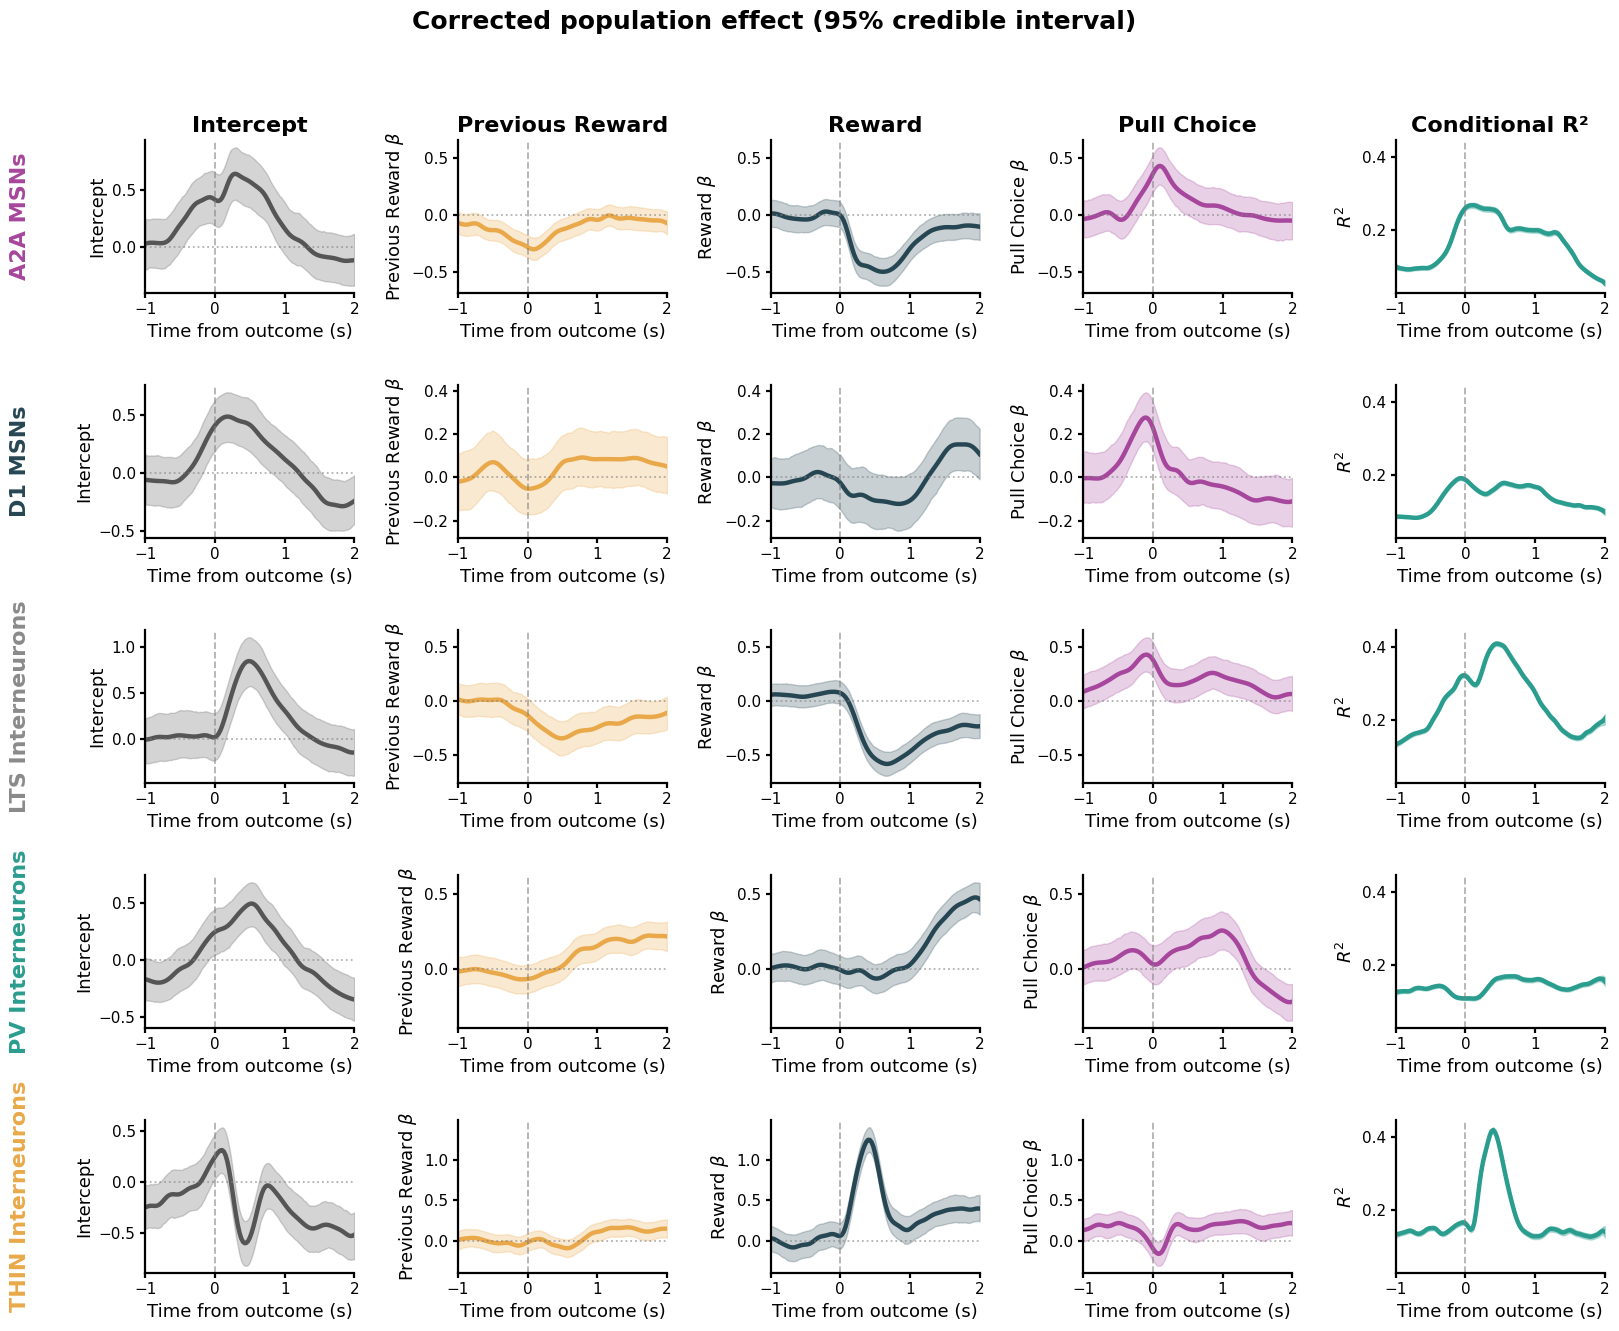

In [40]:
ALIGNMENT = "ChoiceOutcome"  # "GoCue" or "ChoiceOutcome"
CI_LEVEL_KEY = "95"          # must match one of the "ci" keys saved by build_corrected_plot_data_json
JSON_DIR = "Neuronal_data/PlotData_JSON_corrected"

align_label = "outcome" if ALIGNMENT == "ChoiceOutcome" else "go cue"

plot_styles = {
    "intercept": {"display_name": "Intercept", "color": "#555555"},
    "trialOutcome": {"display_name": "Reward", "color": "#264653"},
    "prevTrialOutcome": {"display_name": "Previous Reward", "color": "#E9A94A"},
    "pushPull": {"display_name": "Pull Choice", "color": "#A6469C"},
}
fallback_style = {"color": "C0"}
r2_color = "#2A9D8F"

group_colors = {"pv": "#2A9D8F", "d1": "#264653", "a2a": "#A6469C", "thin": "#E9A94A", "ltsi": "#8A8A8A"}
group_display_names = {
    "pv": "PV Interneurons", "d1": "D1 MSNs", "a2a": "A2A MSNs",
    "thin": "THIN Interneurons", "ltsi": "LTS Interneurons",
}

LINE_WIDTH = 3.2
AXIS_LINE_WIDTH = 1.6
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13
ROWLABEL_FONTSIZE = 16
TICK_FONTSIZE = 11

plt.rcParams.update({
    "axes.linewidth": AXIS_LINE_WIDTH,
    "xtick.major.width": AXIS_LINE_WIDTH,
    "ytick.major.width": AXIS_LINE_WIDTH,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

if not os.path.isdir(JSON_DIR):
    raise FileNotFoundError(
        f"'{JSON_DIR}' does not exist yet. Run the JSON export step "
        "(the build_corrected_plot_data_json loop) first, in the same "
        "working directory, so the JSON files are created before plotting."
    )

# Load every group's JSON for this alignment
data_by_group = {}
for fname in sorted(os.listdir(JSON_DIR)):
    if fname.endswith(f"{ALIGNMENT}.json"):
        with open(os.path.join(JSON_DIR, fname), "r") as f:
            payload = json.load(f)
        data_by_group[payload["group"]] = payload

if not data_by_group:
    raise FileNotFoundError(f"No JSON files found for alignment {ALIGNMENT} in {JSON_DIR}")

group_list = list(data_by_group.keys())
n_groups = len(group_list)

example_payload = next(iter(data_by_group.values()))
all_pred_names = list(example_payload["predictors"].keys())
n_cols = len(all_pred_names) + 1  # predictors + R2

# Shared y-limits for the R2 column, across all groups
all_r2_low = np.concatenate([np.array(d["r2"]["ci"][CI_LEVEL_KEY]["low"]) for d in data_by_group.values()])
all_r2_high = np.concatenate([np.array(d["r2"]["ci"][CI_LEVEL_KEY]["high"]) for d in data_by_group.values()])
r2_y_min, r2_y_max = np.nanmin(all_r2_low), np.nanmax(all_r2_high)
r2_pad = 0.05 * (r2_y_max - r2_y_min if r2_y_max > r2_y_min else 1.0)
shared_r2_ylim = (r2_y_min - r2_pad, r2_y_max + r2_pad)

fig, axs = plt.subplots(
    nrows=n_groups, ncols=n_cols,
    figsize=(3.4 * n_cols, 2.6 * n_groups),
    sharex=False, sharey=False, squeeze=False,
)

for row, neur in enumerate(group_list):
    payload = data_by_group[neur]
    t_sec = np.array(payload["time_sec"])
    row_color = group_colors.get(neur, "#333333")

    # Shared y-limits across non-intercept predictors, this row
    non_intercept_names = [p for p in all_pred_names if p != "intercept"]
    if non_intercept_names:
        all_low = np.concatenate([np.array(payload["predictors"][p]["ci"][CI_LEVEL_KEY]["low"]) for p in non_intercept_names])
        all_high = np.concatenate([np.array(payload["predictors"][p]["ci"][CI_LEVEL_KEY]["high"]) for p in non_intercept_names])
        y_min, y_max = np.nanmin(all_low), np.nanmax(all_high)
        pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
        shared_ylim = (y_min - pad, y_max + pad)
    else:
        shared_ylim = None

    for p, pred_name in enumerate(all_pred_names):
        ax = axs[row, p]
        style = plot_styles.get(pred_name, {**fallback_style, "display_name": pred_name})
        curve = payload["predictors"][pred_name]

        mu = np.array(curve["mean"])
        low = np.array(curve["ci"][CI_LEVEL_KEY]["low"])
        high = np.array(curve["ci"][CI_LEVEL_KEY]["high"])

        ax.plot(t_sec, mu, color=style["color"], lw=LINE_WIDTH)
        ax.fill_between(t_sec, low, high, color=style["color"], alpha=0.25)
        ax.axvline(0, color="gray", linestyle="--", alpha=0.6, lw=1.3)
        ax.axhline(0, color="gray", linestyle=":", alpha=0.6, lw=1.3)
        ax.set_xlim(t_sec[0], t_sec[-1])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if pred_name != "intercept" and shared_ylim is not None:
            ax.set_ylim(shared_ylim)

        if row == 0:
            ax.set_title(style["display_name"], fontsize=TITLE_FONTSIZE, fontweight="bold")
        ax.set_xlabel(f"Time from {align_label} (s)", fontsize=LABEL_FONTSIZE)

        ylabel = style["display_name"] if p == 0 else style["display_name"] + r" $\beta$"
        ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)

    # R2 column
    ax_r2 = axs[row, len(all_pred_names)]
    r2 = payload["r2"]
    r2_mean = np.array(r2["mean"])
    r2_low = np.array(r2["ci"][CI_LEVEL_KEY]["low"])
    r2_high = np.array(r2["ci"][CI_LEVEL_KEY]["high"])
    n_obs = np.array(r2["n_obs"])
    low_n_mask = n_obs < r2["min_n"]

    ax_r2.plot(t_sec, r2_mean, color=r2_color, lw=LINE_WIDTH)
    ax_r2.fill_between(t_sec, r2_low, r2_high, color=r2_color, alpha=0.3)
    ax_r2.fill_between(
        t_sec, 0, 1, where=low_n_mask,
        color="gray", alpha=0.15, transform=ax_r2.get_xaxis_transform(),
    )
    ax_r2.axvline(0, color="gray", linestyle="--", alpha=0.6, lw=1.3)
    ax_r2.axhline(0, color="gray", linestyle=":", alpha=0.6, lw=1.3)
    ax_r2.set_xlim(t_sec[0], t_sec[-1])
    ax_r2.set_ylim(shared_r2_ylim)
    ax_r2.spines["top"].set_visible(False)
    ax_r2.spines["right"].set_visible(False)

    if row == 0:
        ax_r2.set_title("Conditional R\u00b2", fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax_r2.set_xlabel(f"Time from {align_label} (s)", fontsize=LABEL_FONTSIZE)
    ax_r2.set_ylabel(r"$R^2$", fontsize=LABEL_FONTSIZE)

    axs[row, 0].annotate(
        group_display_names.get(neur, neur),
        xy=(-0.6, 0.5), xycoords="axes fraction",
        rotation=90, va="center", ha="center",
        fontsize=ROWLABEL_FONTSIZE, fontweight="bold", color=row_color,
    )

fig.suptitle(
    f"Corrected population effect ({CI_LEVEL_KEY}% credible interval)",
    fontsize=TITLE_FONTSIZE + 2, fontweight="bold", y=1.02,
)
plt.tight_layout(rect=[0.035, 0, 1, 0.98])
plt.savefig(f"corrected_population_grid_{ALIGNMENT}_CI{CI_LEVEL_KEY}.png", dpi=300, bbox_inches="tight")
plt.show()
